In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [2]:
# Load 028 transect
transect = load_transect(config.TRANSECT_028_OUTPUT)

transect.list_files()

# Select all 5 files from transect 028
cube = transect.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
# cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_125028_1  | shape=(1329, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_125028_2  | shape=(2011, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_125028_3  | shape=(2282, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_125028_4  | shape=(2457, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_125028_5  | shape=(1948, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_125028_1
  rad_uhi_20241029_125028_1: Using GRIDDED format (T=1329, S=968)
   • rad_uhi_20241029_125028_2
   • rad_uhi_20241029_125028_2
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
   • rad_uhi_20241029_125028_3
   • rad_uhi_20241029_125028_3
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
   • rad_uhi_20241029_125028_4
   • rad_uhi_

In [3]:
# Apply illumination correction
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 5 files...
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[0.00000000e+00, 8.00363868e-02, 3.38807702e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         9.79862548e-03, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 6.24412894e-01, 0.00000000e+00, ...,
         2.43312144e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         4.49576187e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.18552887e+00, ...,
         2.34972164e-01, 0.00000000e+00, 0.00000000e+00],
        [9.47257459e-01, 0.00000000e+00, 0.00000000e+00, ...,
         3.01917344e-01, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.15298668e+02, 1.14839525e+01, 3.45664215e-03],
        [0.00000000e+00, 1.00000000e+00, 9.11504328e-01, ...,
         2.32659373e-02, 2.43540382e+00, 4.57144403e+00],
        [0.00000000e+00, 

In [4]:
cube.apply_spectral_smoothing(method="gaussian", gaussian_sigma=5.0)

💾 Found cached smoothing (gaussian, corrected data) - loading from disk (much faster!)
📂 Loading saved spectral smoothing (gaussian, corrected data) from 5 files...
   rad_uhi_20241029_125028_1: method=gaussian
   rad_uhi_20241029_125028_1: method=gaussian
   rad_uhi_20241029_125028_2: method=gaussian
   rad_uhi_20241029_125028_2: method=gaussian
   rad_uhi_20241029_125028_3: method=gaussian
   rad_uhi_20241029_125028_3: method=gaussian
   rad_uhi_20241029_125028_4: method=gaussian
   rad_uhi_20241029_125028_4: method=gaussian
   rad_uhi_20241029_125028_5: method=gaussian
✅ Loaded spectral smoothing from disk (saved computation time!)
   rad_uhi_20241029_125028_5: method=gaussian
✅ Loaded spectral smoothing from disk (saved computation time!)


array([[[ 0.4532221 ,  0.53937715,  0.63120246, ...,  1.329839  ,
          1.0979766 ,  0.8896462 ],
        [ 0.6584392 ,  0.804807  ,  0.96267426, ...,  0.45877442,
          0.3839115 ,  0.3138889 ],
        [ 0.12631023,  0.16660938,  0.21990718, ...,  0.77975476,
          0.6993797 ,  0.6094591 ],
        ...,
        [ 0.5135691 ,  0.6470479 ,  0.79466134, ...,  0.9414678 ,
          0.82947934,  0.7143122 ],
        [ 0.29588312,  0.37845287,  0.48172387, ...,  1.260789  ,
          1.1231327 ,  0.96826327],
        [ 0.65205956,  0.653936  ,  0.68873525, ...,  0.93748766,
          0.72272384,  0.5440005 ]],

       [[ 0.69635546,  0.8777972 ,  1.0773233 , ..., 12.1487255 ,
         11.606293  , 10.720098  ],
        [ 1.0415434 ,  1.2013056 ,  1.3412076 , ...,  2.8468373 ,
          3.069253  ,  3.2957566 ],
        [ 0.98259646,  1.1279558 ,  1.2616764 , ...,  1.9515684 ,
          1.8102084 ,  1.6635032 ],
        ...,
        [ 0.4940042 ,  0.58075166,  0.6652872 , ...,  

In [5]:
cube.apply_wavelength_filter(wavelength_range=(490, 700))

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-700 nm
✂️  Filtered wavelengths: 119
📉 Range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (10027, 968, 119)
   Memory: 4.30 GB

✅ Datacube shape after filtering: (10027, 968, 119)
   Memory: 4.30 GB


array([[[1.0602641 , 1.0583838 , 1.0573272 , ..., 1.147487  ,
         1.1758505 , 1.2136223 ],
        [1.0108603 , 1.0125942 , 1.0151335 , ..., 1.1057171 ,
         1.107135  , 1.1100338 ],
        [1.0743815 , 1.0689347 , 1.064552  , ..., 1.1011469 ,
         1.105848  , 1.1103718 ],
        ...,
        [1.1252737 , 1.1158714 , 1.1075379 , ..., 1.1134797 ,
         1.1248407 , 1.1457047 ],
        [1.1079551 , 1.1031226 , 1.0986322 , ..., 1.1835234 ,
         1.1935018 , 1.2048317 ],
        [1.0862495 , 1.0863831 , 1.0884625 , ..., 1.1284868 ,
         1.1320375 , 1.139473  ]],

       [[1.0165827 , 1.0158072 , 1.0160393 , ..., 1.0780658 ,
         1.1072857 , 1.1518384 ],
        [1.033642  , 1.0300514 , 1.0271373 , ..., 1.0841676 ,
         1.1052788 , 1.1326934 ],
        [0.98506564, 0.98905784, 0.9936069 , ..., 1.0812087 ,
         1.087947  , 1.098398  ],
        ...,
        [0.99218565, 1.0052707 , 1.020384  , ..., 1.1385047 ,
         1.1505976 , 1.1662767 ],
        [1.1

🎨 RGB CROPS (Before normalization):
📂 Imported 14 ROIs from ./rois/028_new.json

📂 ROI Collection (14 ROIs):
 1. 'rust': 58 pixels
     Slit range:  193 - 222
     Track range: 1255 - 1261
 2. 'sediment': 541 pixels
     Slit range:   28 - 967
     Track range: 3604 - 9735
 3. '1_halo': 50 pixels
     Slit range:  575 - 649
     Track range: 5154 - 5168
 4. '1_arms': 135 pixels
     Slit range:  549 - 682
     Track range: 5146 - 5178
 5. '1_dark': 149 pixels
     Slit range:  538 - 688
     Track range: 5150 - 5179
 6. '1_bomb': 148 pixels
     Slit range:  595 - 636
     Track range: 5156 - 5163
 7. '2_dark': 145 pixels
     Slit range:  150 - 280
     Track range: 1250 - 1271
 8. '2_halo': 96 pixels
     Slit range:  174 - 240
     Track range: 1253 - 1266
 9. '3_halo': 143 pixels
     Slit range:  721 - 786
     Track range: 5587 - 5600
10. '3_dark': 130 pixels
     Slit range:  723 - 809
     Track range: 5583 - 5604
11. '3_bomb': 79 pixels
     Slit range:  742 - 764
     Track r

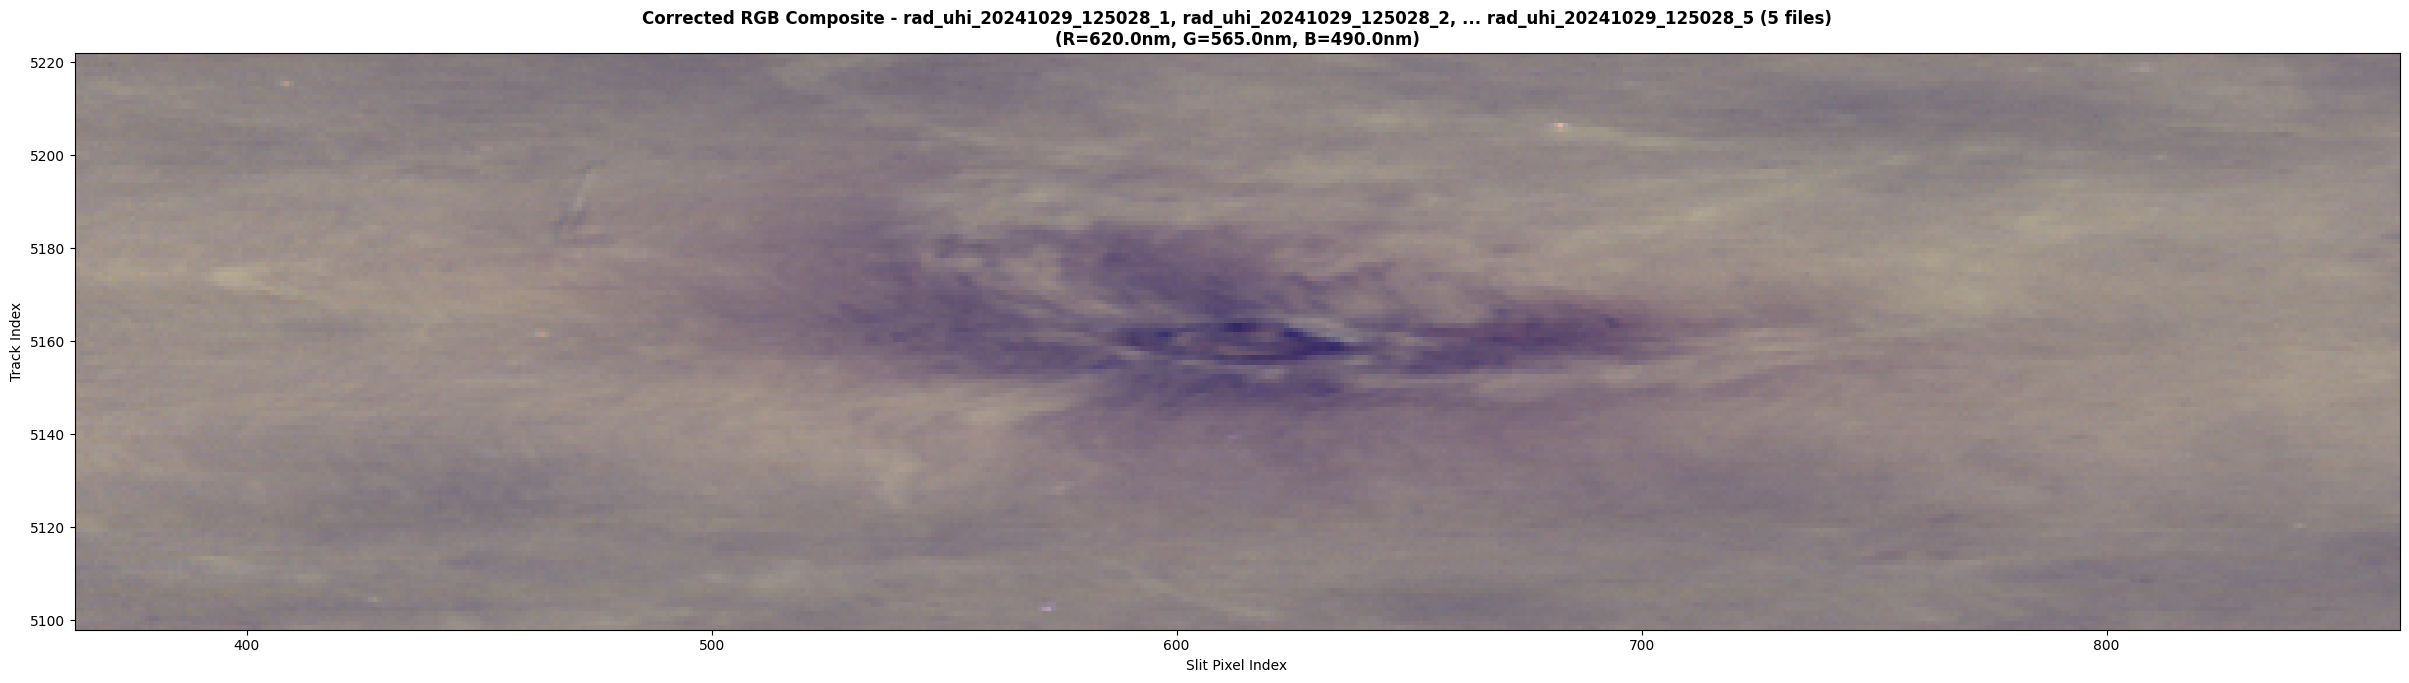


📸 Bomb 2:
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)


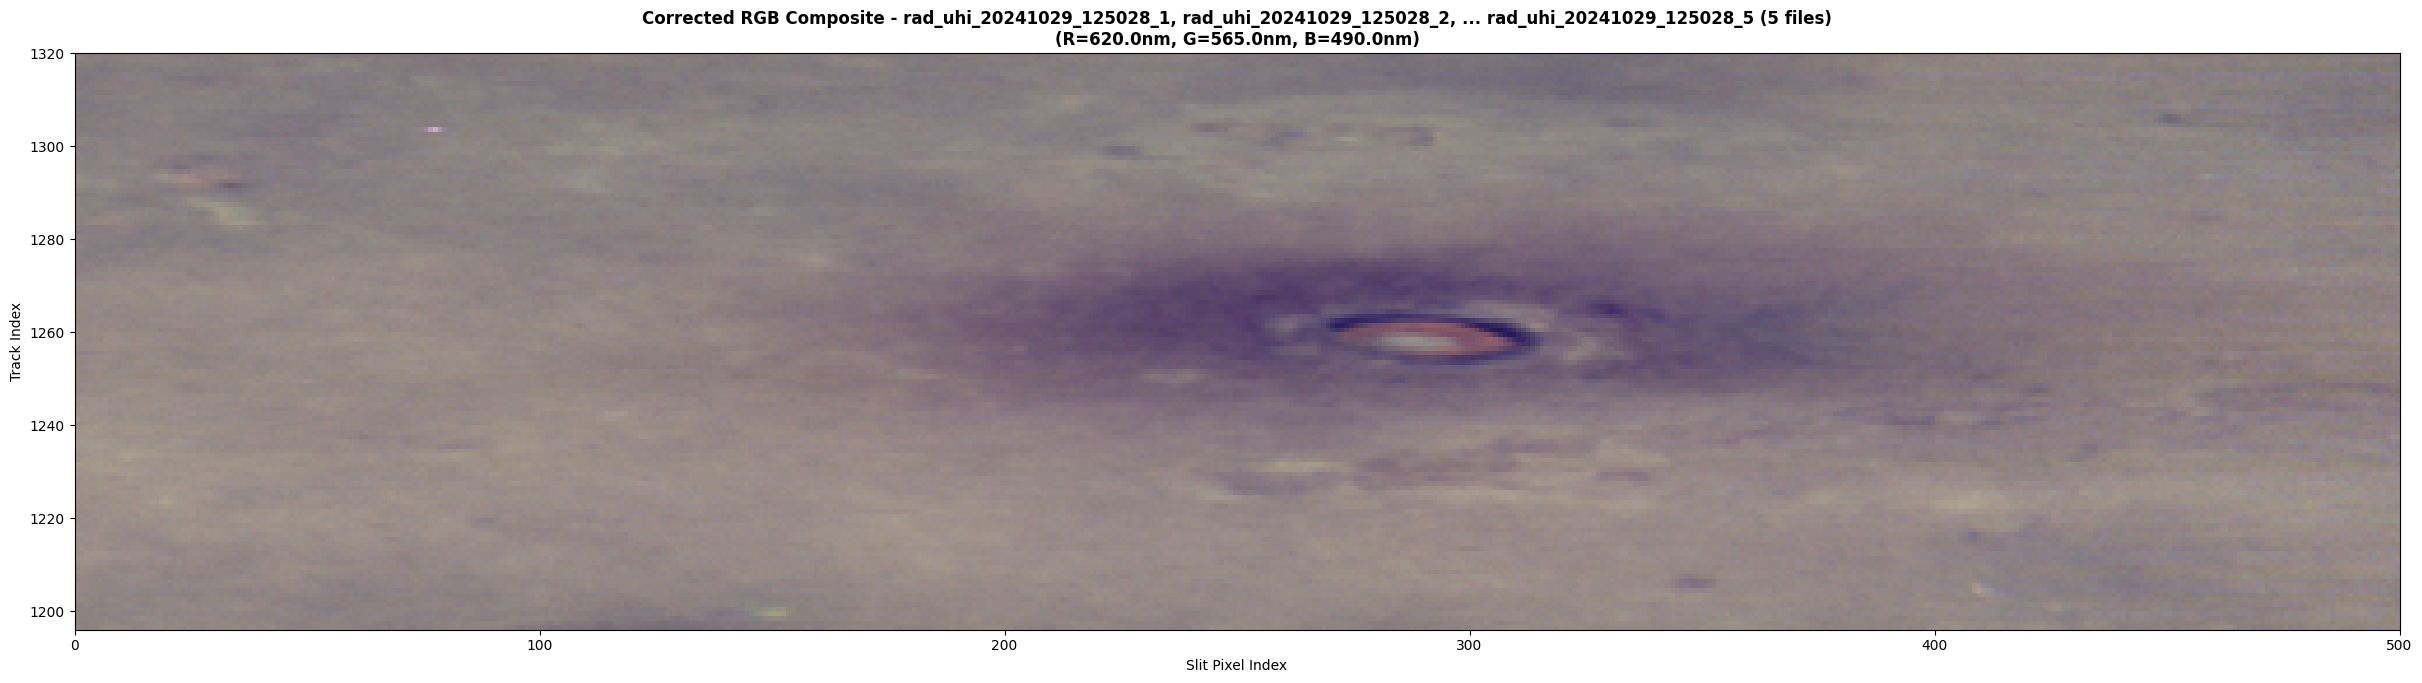


📸 Bomb 3:
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)


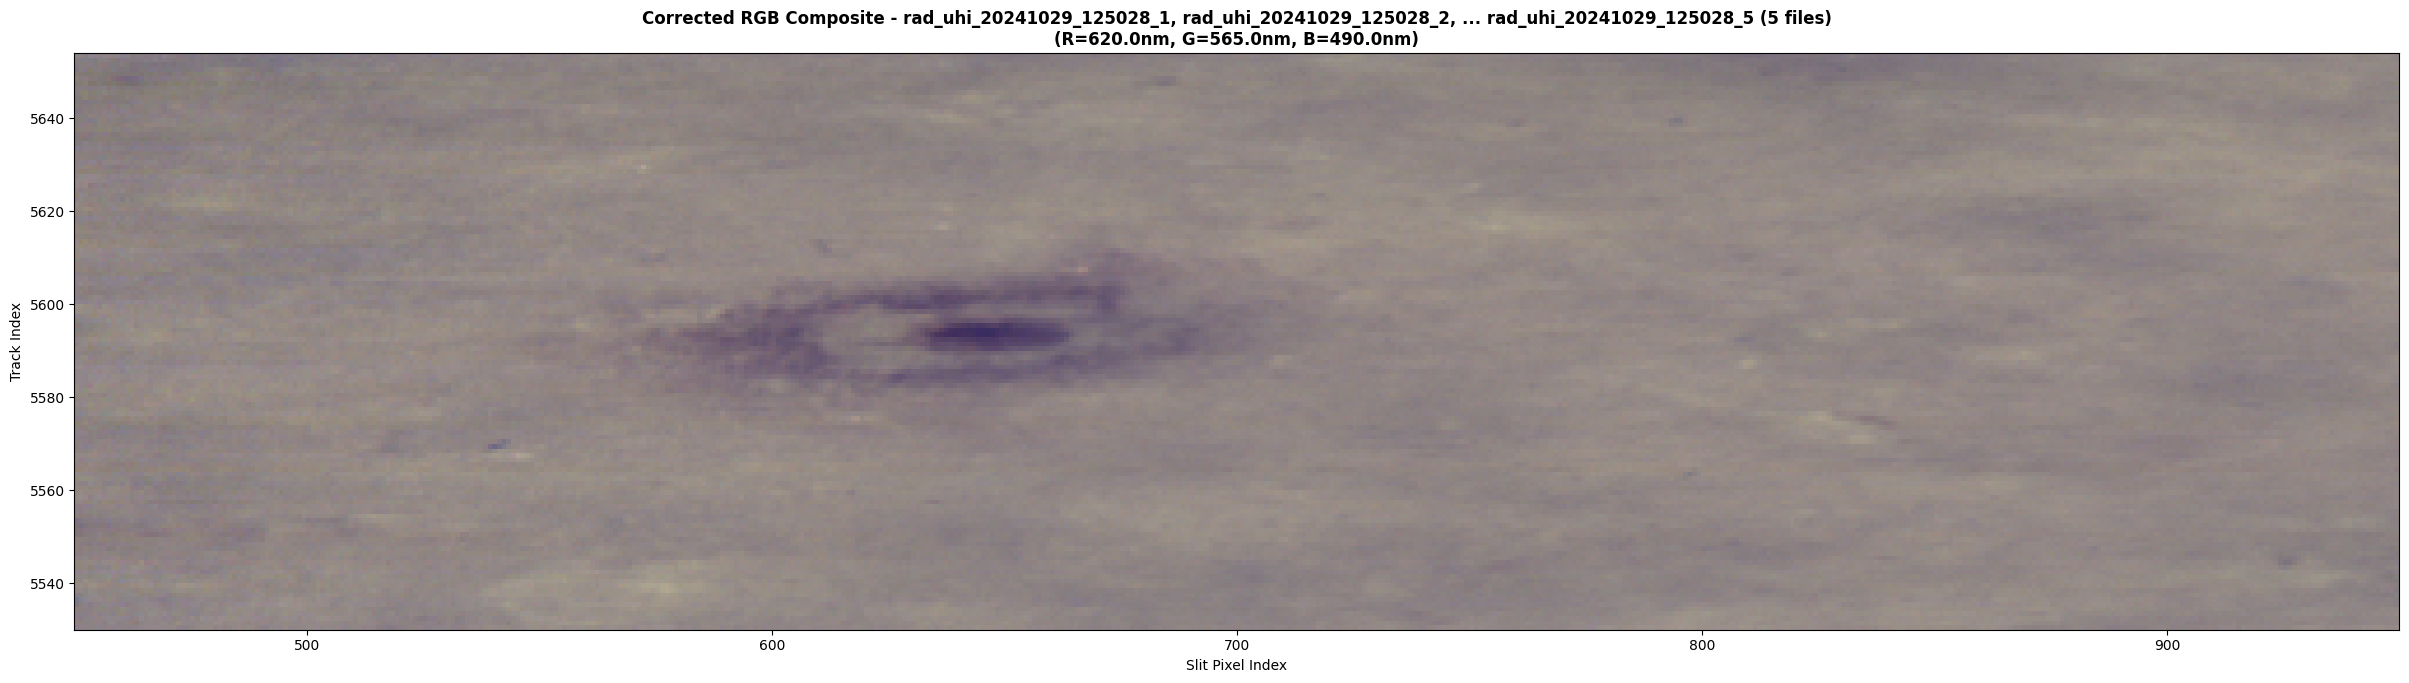


📸 Dark pits:
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)


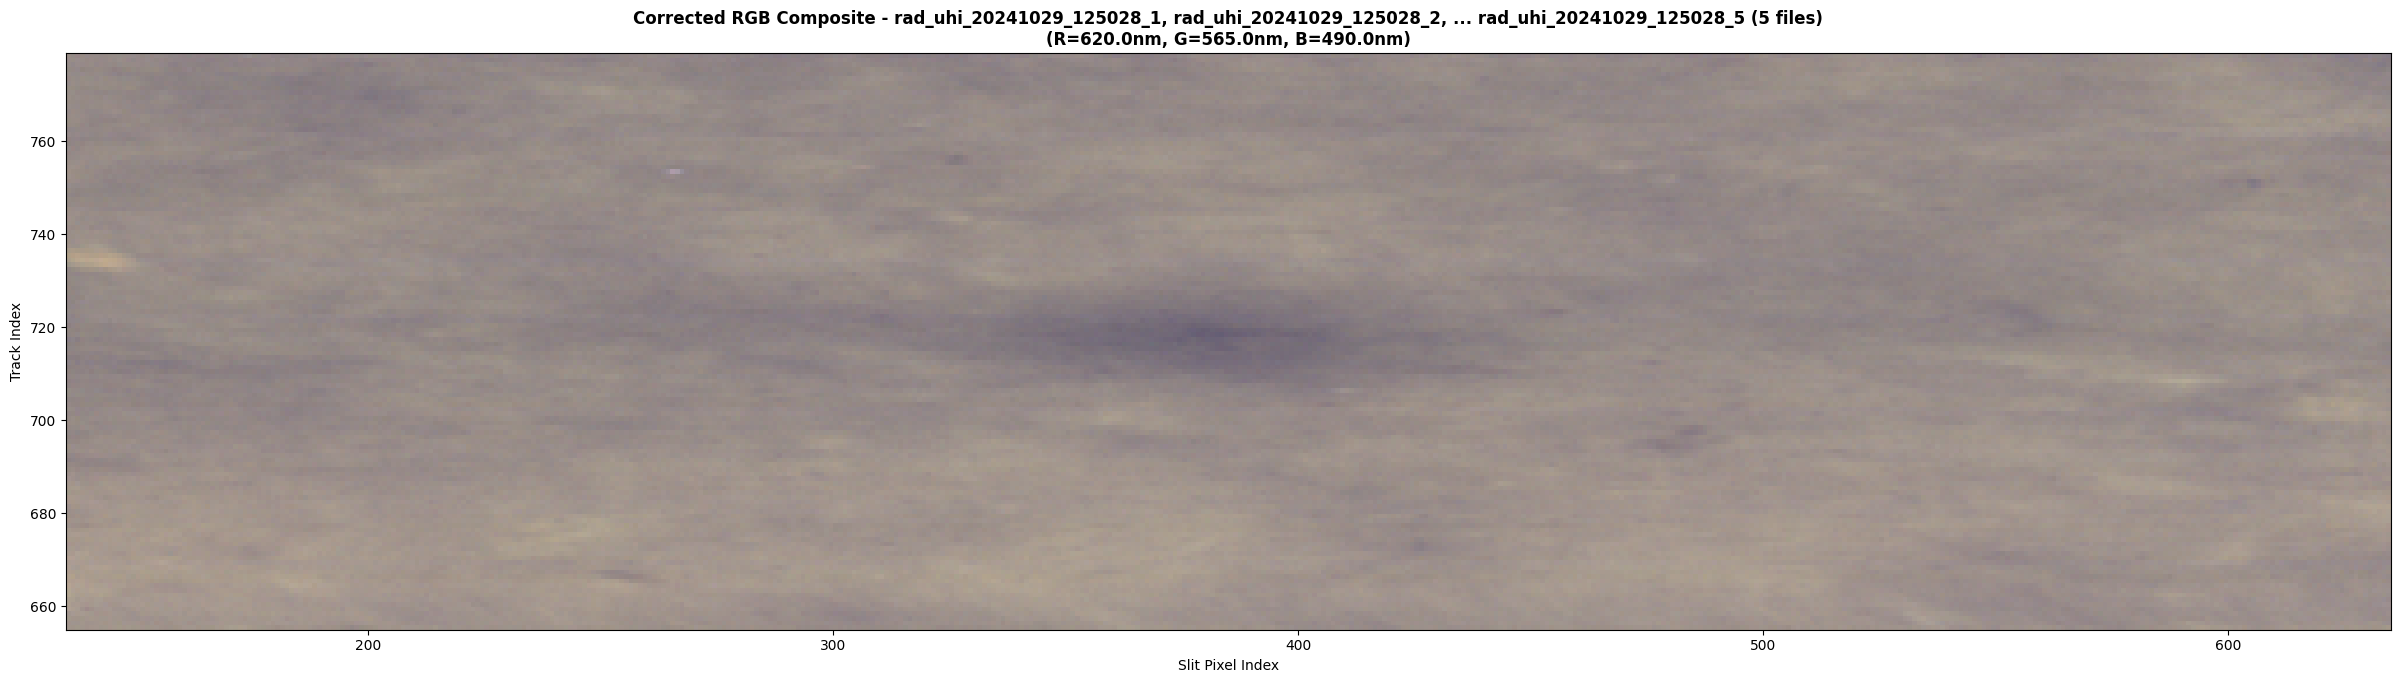


📸 Between 1-2:
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 4026 → local track 4026, slit 582
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [3964:4088], slit [332:832]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[332, 832], y=[3964, 4088]
📐 Image shape after transformations: (124, 500, 3)
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 4026 → local track 4026, slit 582
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [3964:4088], slit [332:832]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[332, 832], y=[3964, 4088]
📐 Image shape after transformations: (124, 500, 3)


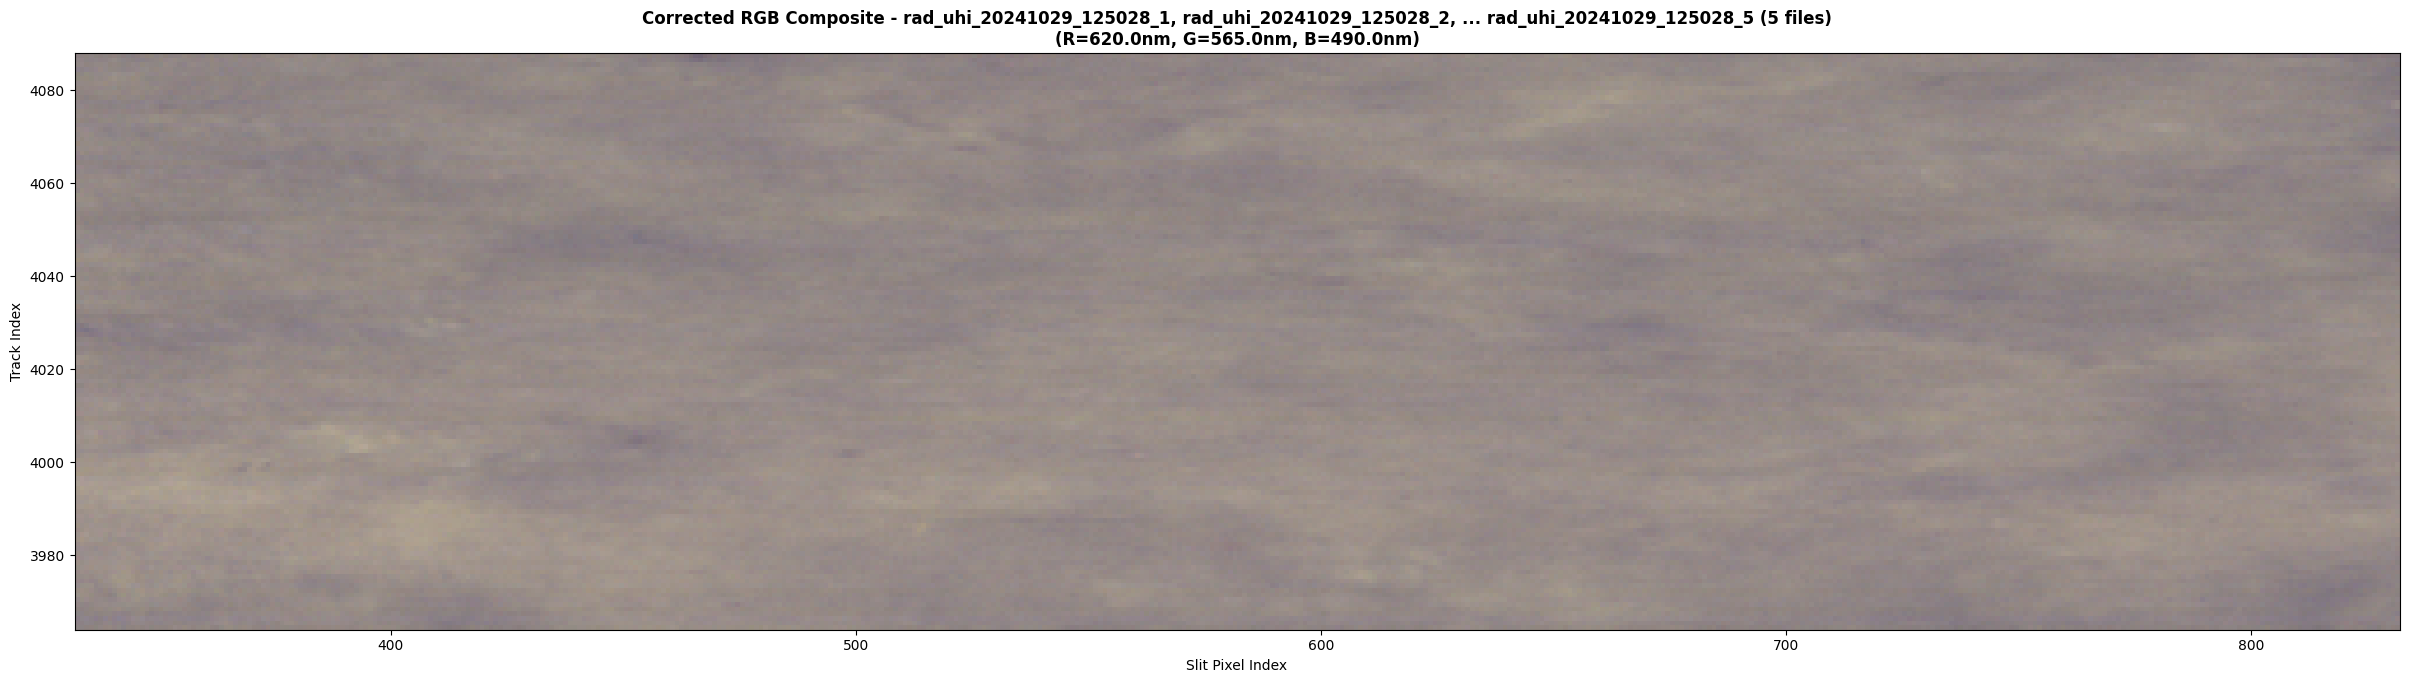


📸 Bomb 1:
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)


e:\mjosa_complete\gref4hsi\mjosa_code\utils\uhi\georef.py:7627: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


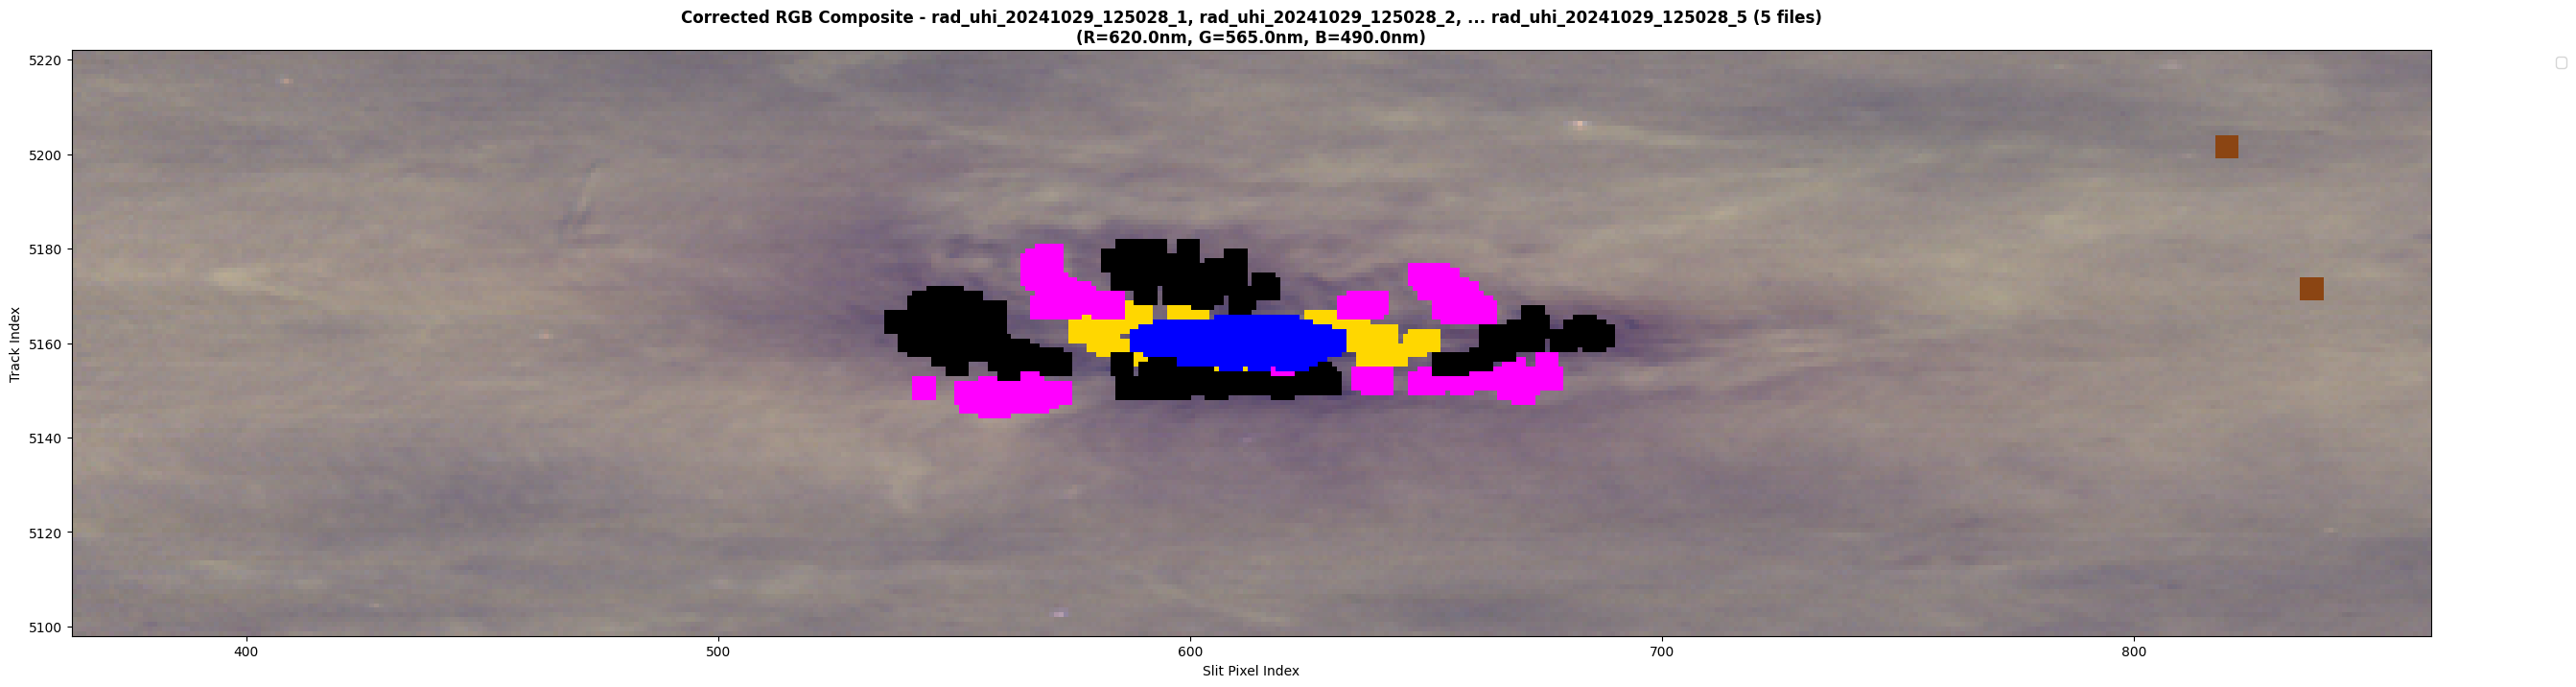


📸 Bomb 2:
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)


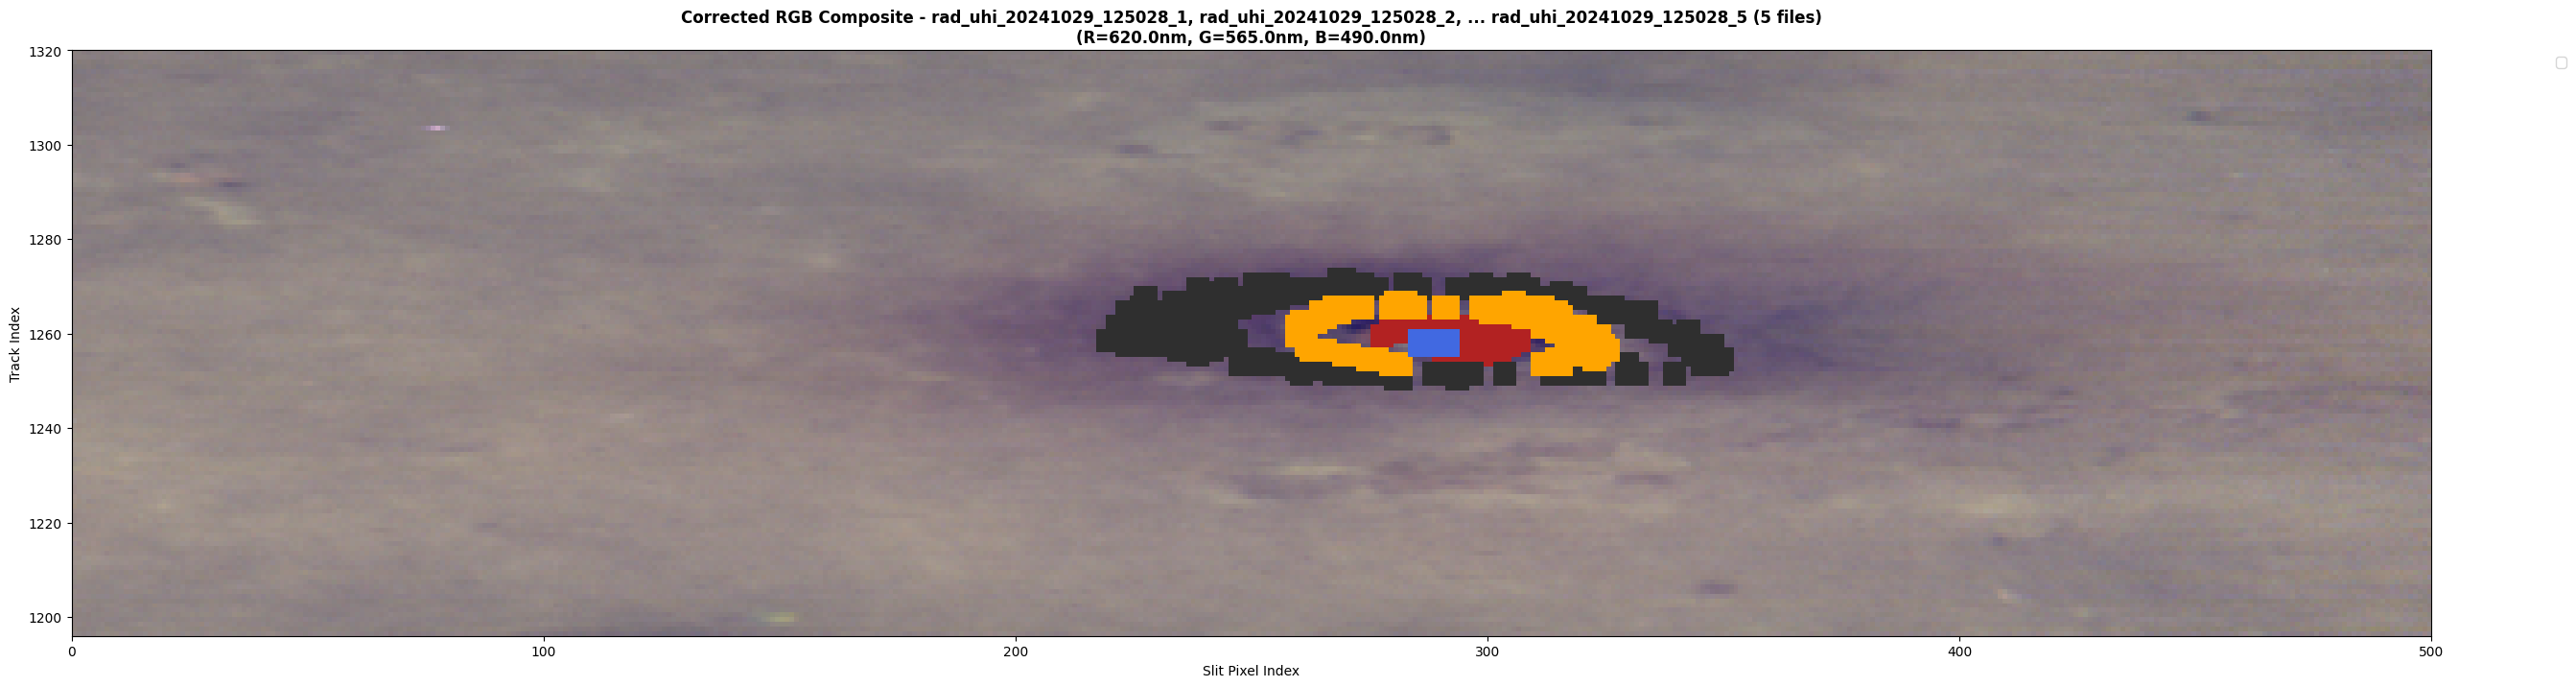


📸 Bomb 3:
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)


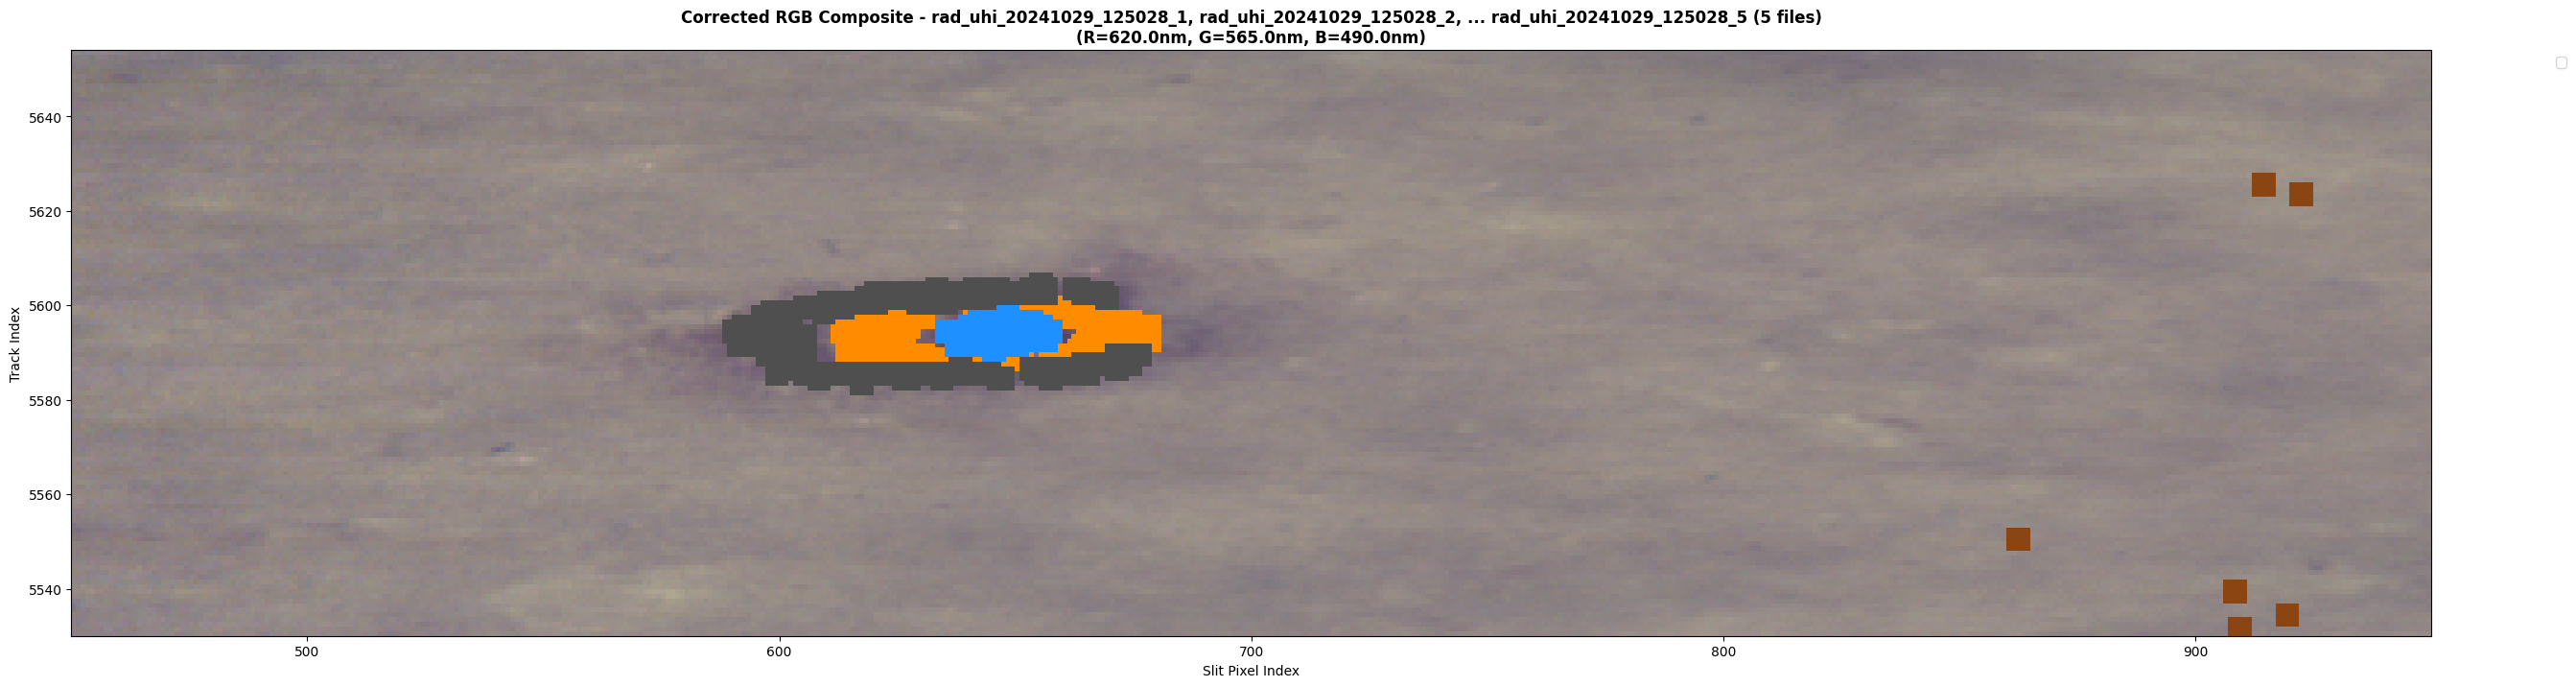


📸 Dark pits:
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)


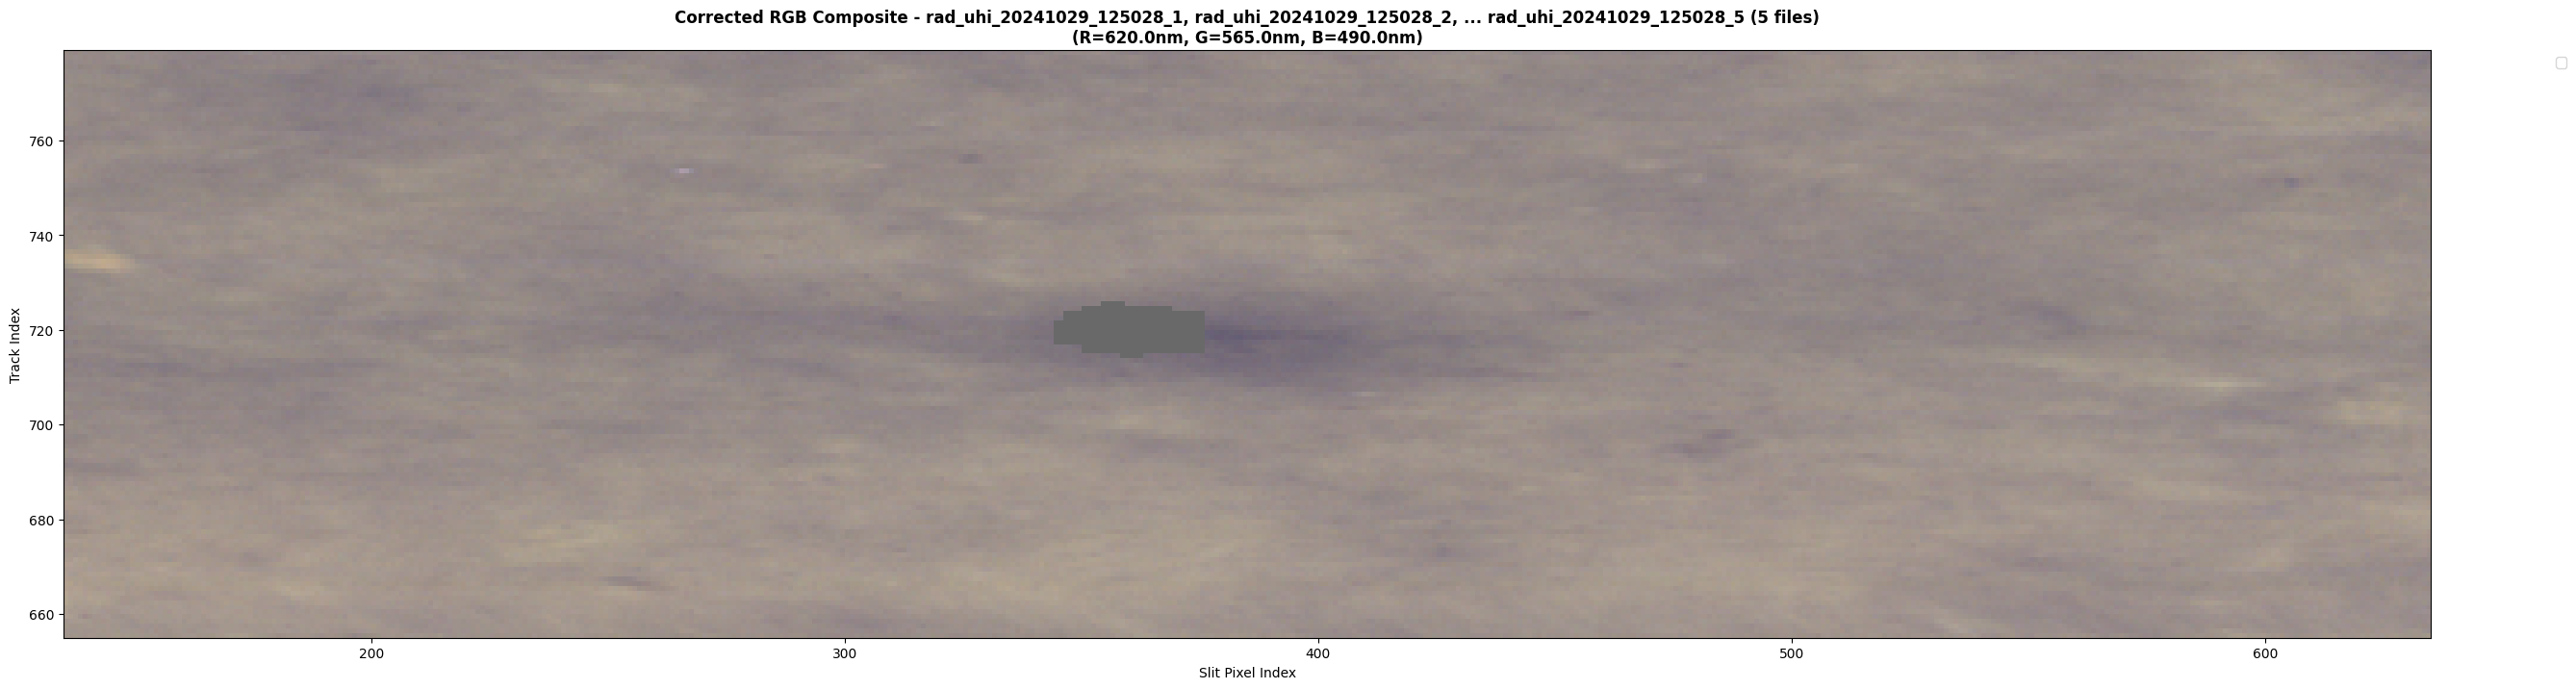


📸 Between 1-2:
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 4026 → local track 4026, slit 582
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [3964:4088], slit [332:832]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[332, 832], y=[3964, 4088]
📐 Image shape after transformations: (124, 500, 3)
📐 Crop center: global track 4026 → local track 4026, slit 582
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [3964:4088], slit [332:832]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[332, 832], y=[3964, 4088]
📐 Image shape after transformations: (124, 500, 3)


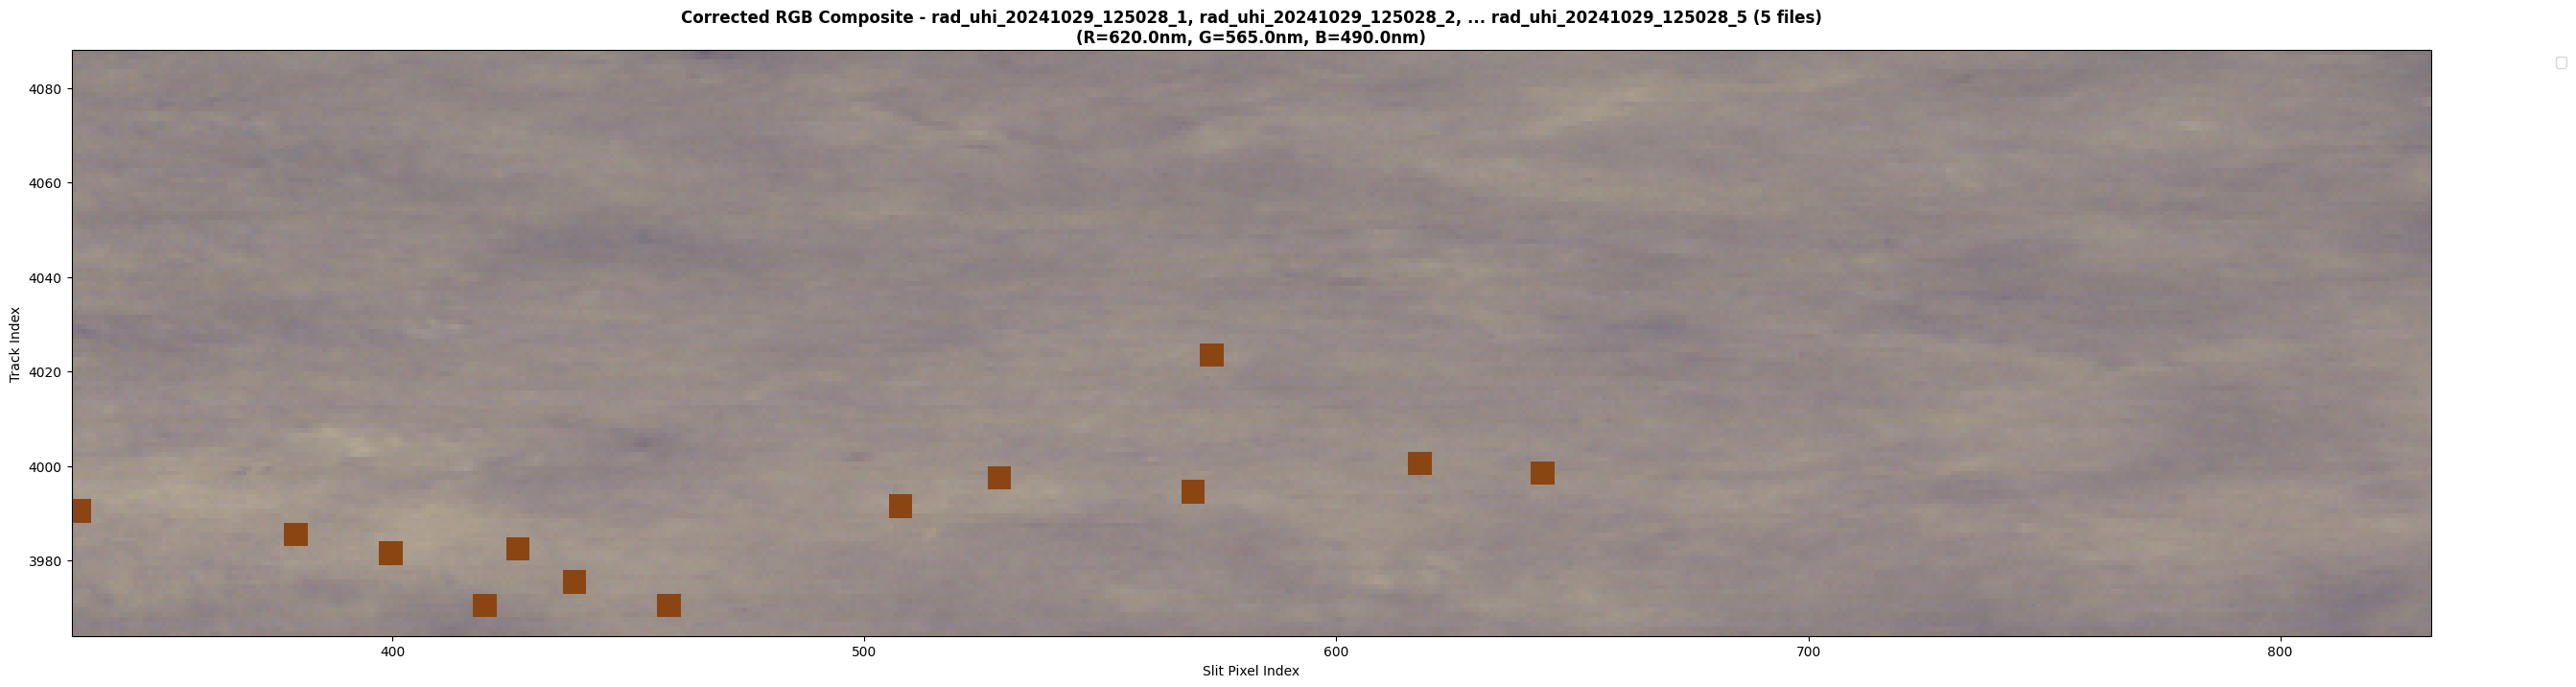

In [6]:
# Plot RGB crops BEFORE normalization (to see true colors)
print("🎨 RGB CROPS (Before normalization):")

# Import ROIs first
cube.import_rois("./rois/028_new.json")
cube.list_rois()

# Define your crop regions
crop_regions = [
    {"track": 5160, "slit": 613, "label": "Bomb 1"},
    {"track": 1258, "slit": 250, "label": "Bomb 2"},
    {"track": 5592, "slit": 700, "label": "Bomb 3"},
    {"track": 717, "slit": 385, "label": "Dark pits"},
    {"track": 4026, "slit": 582, "label": "Between 1-2"},
]

# Plot RGB for each crop WITH ROIs
for region in crop_regions:
    print(f"\n📸 {region['label']}:")
    cube.plot_rgb(
        use_corrected=True,
        figsize=(30, 8.32),
        crop_center_track=region["track"],
        crop_center_slit=region["slit"],
        crop_width=500,
        crop_aspect_ratio=4,
        flip_axes=True,
        flip_horizontal=True,
        show_file_boundaries=False,
        # RGB wavelengths (true color)
        # ROI overlay
    )

# Plot RGB for each crop WITH ROIs
for region in crop_regions:
    print(f"\n📸 {region['label']}:")
    cube.plot_rgb(
        use_corrected=True,
        figsize=(30, 8.32),
        crop_center_track=region["track"],
        crop_center_slit=region["slit"],
        crop_width=500,
        crop_aspect_ratio=4,
        flip_axes=True,
        flip_horizontal=True,
        show_file_boundaries=False,
        # RGB wavelengths (true color)
        # ROI overlay
        roi_collection="all",  # Show all ROIs from 028_new.json
        roi_overlay_mode="solid",
        roi_solid_pixel_size=5,
        roi_legend_loc="outside",
        roi_marker_edgewidth=0,
        roi_legend_markersize=50,
    )

In [7]:
# Import ROIs
cube.import_rois("./rois/028_new.json")
cube.list_rois()

📂 Imported 14 ROIs from ./rois/028_new.json

📂 ROI Collection (14 ROIs):
 1. 'rust': 58 pixels
     Slit range:  193 - 222
     Track range: 1255 - 1261
 2. 'sediment': 541 pixels
     Slit range:   28 - 967
     Track range: 3604 - 9735
 3. '1_halo': 50 pixels
     Slit range:  575 - 649
     Track range: 5154 - 5168
 4. '1_arms': 135 pixels
     Slit range:  549 - 682
     Track range: 5146 - 5178
 5. '1_dark': 149 pixels
     Slit range:  538 - 688
     Track range: 5150 - 5179
 6. '1_bomb': 148 pixels
     Slit range:  595 - 636
     Track range: 5156 - 5163
 7. '2_dark': 145 pixels
     Slit range:  150 - 280
     Track range: 1250 - 1271
 8. '2_halo': 96 pixels
     Slit range:  174 - 240
     Track range: 1253 - 1266
 9. '3_halo': 143 pixels
     Slit range:  721 - 786
     Track range: 5587 - 5600
10. '3_dark': 130 pixels
     Slit range:  723 - 809
     Track range: 5583 - 5604
11. '3_bomb': 79 pixels
     Slit range:  742 - 764
     Track range: 5590 - 5597
12. 'dark_pits': 6

In [8]:
cube.apply_spectral_normalization(method="l2")

📐 SPECTRAL NORMALIZATION: L2
📊 Datacube shape: (10027, 968, 119)
🌊 Wavelengths: 119 (490.2 - 699.4 nm)


KeyboardInterrupt: 

In [ ]:
def plot_multiple_crops(
    cube,
    crop_regions,
    wavelength_target=660,
    derivative_order=0,
    derivative_window=2,
    crop_width=500,
    crop_aspect_ratio=4,
    display_aspect_ratio=4.0,
    vmin=0.086,
    vmax=0.1,
    use_wavelength_colormap=True,
    flip_axes=True,
    flip_horizontal=True,
    show_file_boundaries=False,
    use_corrected=True,
    **kwargs,
):
    """
    Plot multiple crop regions with the same settings.

    Example:
        crop_regions = [
            {"track": 1258, "slit": 250, "label": "Bomb 2"},
            {"track": 5592, "slit": 700, "label": "Bomb 3"},
        ]

        plot_multiple_crops(
            cube,
            crop_regions,
            wavelength_target=660,
            vmin=0.086,
            vmax=0.1,
        )
    """
    print(f"📊 Plotting {len(crop_regions)} regions...")
    print(f"   Wavelength: {wavelength_target} nm, Derivative: {derivative_order}")
    print(f"   Normalization: vmin={vmin}, vmax={vmax}\n")

    for i, region in enumerate(crop_regions, 1):
        label = region.get("label", f"Region {i}")
        print(
            f"[{i}/{len(crop_regions)}] {label}: track={region['track']}, slit={region['slit']}"
        )

        cube.plot_rgb(
            use_corrected=use_corrected,
            figsize=(30, 8.32),
            flip_axes=flip_axes,
            flip_horizontal=flip_horizontal,
            crop_center_track=region["track"],
            crop_center_slit=region["slit"],
            crop_width=crop_width,
            show_file_boundaries=show_file_boundaries,
            crop_aspect_ratio=crop_aspect_ratio,
            display_aspect_ratio=display_aspect_ratio,
            use_wavelength_colormap=use_wavelength_colormap,
            wavelength_colormap_target=wavelength_target,
            derivative_order=derivative_order,
            derivative_window=derivative_window,
            vmin=vmin,
            vmax=vmax,
            **kwargs,
        )

    print(f"\n✅ All {len(crop_regions)} regions plotted!")

In [ ]:
# Define your crop regions once
crop_regions = [
    {"track": 5160, "slit": 613, "label": "Bomb 1"},
    {"track": 1258, "slit": 250, "label": "Bomb 2"},
    {"track": 5592, "slit": 700, "label": "Bomb 3"},
    {"track": 717, "slit": 385, "label": "Dark pits"},
    {"track": 4026, "slit": 582, "label": "Between 1-2"},
]

# Plot all regions with the same settings - tweak once here!
plot_multiple_crops(
    cube,
    crop_regions,
    crop_width=500,
    # this is for normal
    derivative_order=0,
    vmin=0.086,
    vmax=0.1,
    wavelength_target=677,
    # this is for derivaitve
    # derivative_order=1,
    # vmin=-0.000206,
    # vmax=0.000300,
    # wavelength_target=660,
)

---

---

---

---

---

---

---

---

# greyscale for 057


In [ ]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [ ]:
# ========== TRANSECT 057 (DEFAULT) ==========
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()

In [ ]:
cube.apply_illumination_correction_v2()

In [ ]:
cube.apply_spectral_smoothing(method="gaussian", gaussian_sigma=5.0)

In [ ]:
cube.apply_wavelength_filter(wavelength_range=(490, 700))

In [ ]:
cube.apply_spectral_normalization(method="l2")

In [ ]:
cube.plot_georef(
    use_corrected=True,
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    use_wavelength_colormap=True,
    wavelength_colormap_target=677,
    # vmin=0.09,
    # vmax=0.15,
    # make it use the same minmax as the other greyscales
    vmin=0.086,
    vmax=0.1,
    # Let it auto-compute to see actual data range
    colorbar_fraction=0.006,  # Width
    colorbar_pad=0.04,  # Padding (now works!)
    colorbar_shrink=0.5,  # Height (now works!)
    figsize=(50, 20),
)